# TCGA Pan-Cancer RNA-seq 기반 암종 분류와 해석 가능한 바이오마커 발굴

**프로젝트 주제**: Classical Machine Learning과 MLP latent representation 비교  
**목표**: TCGA Pan-Cancer Atlas RNA-seq 데이터를 이용해 `문제 정의 → 데이터 수집 → 전처리 → 분석/모델링 → 평가 → 해석`의 전체 데이터 과학 프로세스를 완성한다.

이 노트북은 발표자료에 들어갈 핵심 실행 흐름만 보여주고, 세부 함수들은 `tcga_project/` 폴더의 `.py` 파일로 분리했다.

**v4 업데이트**
- 20개 암종 시각화에서 색상이 10개만 반복되는 문제를 해결하기 위해 `tab20` 기반 categorical palette와 marker cycle을 명시적으로 사용한다.
- `Top 2,000 variable genes`와 `All usable genes`를 같은 Logistic Regression 기준으로 비교하는 feature-set size comparison section을 추가했다.
- Confusion matrix는 계속 class imbalance를 고려한 **row-normalized** 형태를 발표용 기본 그림으로 사용한다.


## 0. 실행 전 안내

- v4 기본값은 **20개 암종 + 암종별 최대 1000개 sample + top variable genes 2000개**로 설정했다.
- 20개 암종 plot은 더 이상 matplotlib 기본 10색 cycle에 의존하지 않고, `tab20` palette와 marker를 사용한다.
- Confusion matrix는 class imbalance를 고려해 **row-normalized matrix**를 발표용 기본 그림으로 사용한다. raw count matrix는 표로 저장만 한다.
- `UMAP`을 기본값으로 사용한다. 설치되어 있지 않으면 자동으로 t-SNE로 fallback한다.

필요한 경우 아래 명령을 한 번 실행한다.

```python
%pip install -r requirements.txt
```


In [ ]:
# 필요 시 주석을 해제하고 한 번만 실행하세요.
# %pip install -r requirements.txt

## 1. 환경 설정과 패키지 import

기존 랩 코드의 흐름을 유지한다.

- `train_test_split`으로 train/test 분리
- `StandardScaler`는 train set에만 fit
- Logistic Regression / Random Forest / MLP 비교
- PCA와 t-SNE 또는 UMAP으로 고차원 발현 데이터 시각화

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tcga_project.config import (
    ProjectConfig,
    DEFAULT_CANCER_TYPES_5,
    DEFAULT_CANCER_TYPES_10,
    DEFAULT_CANCER_TYPES_20,
    CANCER_FULL_NAMES,
)
from tcga_project.utils import set_global_seed, save_table, print_section
from tcga_project.data import prepare_tcga_expression_dataset, make_demo_gene_expression
from tcga_project.preprocessing import (
    summarize_dataset,
    missing_value_report,
    class_count_table,
    prepare_eda_matrix,
    prepare_model_data,
)
from tcga_project.models import (
    build_classical_models,
    fit_classical_models,
    evaluate_models,
    classification_report_df,
    confusion_matrix_df,
    per_class_accuracy_df,
    top_confusion_pairs,
    get_best_model_name,
)
from tcga_project.experiments import run_feature_set_size_comparison
from tcga_project.interpretation import (
    logistic_top_genes,
    logistic_nonzero_genes,
    random_forest_top_genes,
    overlapping_top_genes,
)
from tcga_project.deep_learning import torch_available, train_mlp_classifier, encode_mlp_latent
from tcga_project.dimensionality import (
    compute_pca,
    compute_embedding,
    compare_kmeans_spaces,
    stratified_sample_indices,
)
from tcga_project.visualization import (
    plot_class_counts,
    plot_expression_distribution,
    plot_palette_preview,
    plot_embedding,
    plot_confusion_matrix,
    plot_metrics_table,
    plot_feature_set_comparison,
    plot_per_class_metric,
    plot_top_confusion_pairs,
    plot_top_genes,
    plot_training_history,
)

set_global_seed(42)
print("Project root:", PROJECT_ROOT)


Project root: /Users/martin/Git/DS-ML/tcga_pancancer_project


## 2. 프로젝트 설정

기본 설정은 **20개 암종 분류**를 목표로 한다.  
`CANCER_TYPES = None`과 `N_TOP_CANCER_TYPES = 20`을 사용하면, clinical CDR과 RNA-seq header를 매칭한 뒤 sample 수가 많은 상위 20개 암종을 자동으로 선택한다.

이미 특정 암종 목록을 고정하고 싶으면 아래처럼 바꿀 수 있다.

```python
CANCER_TYPES = DEFAULT_CANCER_TYPES_20
N_TOP_CANCER_TYPES = None
```


In [2]:
# ===== 사용자가 조정하기 쉬운 주요 설정 =====
DEMO_MODE = False

# 20-class 프로젝트 기본값: top 20 cancer types를 데이터에서 자동 선택
CANCER_TYPES = None            # None이면 모든 암종 후보에서 시작
N_TOP_CANCER_TYPES = 20        # sample 수 기준 상위 20개 암종 자동 선택

# 로컬 RAM 48GB 기준 설정
MAX_SAMPLES_PER_CLASS = 1000   # 큰 class만 cap; class imbalance는 일부 유지됨
TOP_N_GENES = 2000             # main pipeline: train set에서 분산이 큰 2,000개 gene 선택
MAX_MISSING_FRACTION = 0.20    # train set에서 결측 비율이 이보다 큰 gene 제거
EMBEDDING_METHOD = "umap"      # 20개 암종에서는 UMAP 권장. 미설치 시 t-SNE fallback
MAX_SAMPLES_FOR_EMBEDDING = 3000
RUN_MLP = True

# 추가 실험: feature selection 2,000 genes vs all usable genes 비교
RUN_FEATURE_SET_COMPARISON = True
FEATURE_SET_SPECS = [
    {"name": "Top 2,000 variable genes", "top_n_genes": 2000},
    {"name": "All usable genes", "top_n_genes": None},
]

cfg = ProjectConfig(
    project_root=PROJECT_ROOT,
    data_dir=PROJECT_ROOT / "data",
    raw_dir=PROJECT_ROOT / "data" / "raw",
    processed_dir=PROJECT_ROOT / "data" / "processed",
    outputs_dir=PROJECT_ROOT / "outputs",
    figure_dir=PROJECT_ROOT / "outputs" / "figures",
    table_dir=PROJECT_ROOT / "outputs" / "tables",
    cancer_types=CANCER_TYPES,
    n_top_cancer_types=N_TOP_CANCER_TYPES,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    top_n_genes=TOP_N_GENES,
    max_missing_fraction=MAX_MISSING_FRACTION,
    embedding_method=EMBEDDING_METHOD,
    max_samples_for_embedding=MAX_SAMPLES_FOR_EMBEDDING,
    demo_mode=DEMO_MODE,
    run_mlp=RUN_MLP,
    random_state=42,
)
cfg.ensure_dirs()

pd.DataFrame([
    {"setting": "cancer_types", "value": "auto top-N" if cfg.cancer_types is None else ", ".join(cfg.cancer_types)},
    {"setting": "n_top_cancer_types", "value": cfg.n_top_cancer_types},
    {"setting": "max_samples_per_class", "value": cfg.max_samples_per_class},
    {"setting": "top_n_genes_main_pipeline", "value": cfg.top_n_genes},
    {"setting": "max_missing_fraction", "value": cfg.max_missing_fraction},
    {"setting": "embedding_method", "value": cfg.embedding_method},
    {"setting": "max_samples_for_embedding", "value": cfg.max_samples_for_embedding},
    {"setting": "run_feature_set_comparison", "value": RUN_FEATURE_SET_COMPARISON},
])


,setting,value
0,cancer_types,auto top-N
1,n_top_cancer_types,20
2,max_samples_per_class,1000
3,top_n_genes_main_pipeline,2000
4,max_missing_fraction,0.2
5,embedding_method,umap
6,max_samples_for_embedding,3000
7,run_feature_set_comparison,True


## 3. 문제 정의

**입력 X**: 환자 종양 sample의 RNA-seq gene expression profile  
**출력 y**: 해당 sample의 cancer type  
**문제 유형**: multi-class classification

분석 질문은 다음과 같다.

1. RNA-seq gene expression만으로 여러 암종을 분류할 수 있는가?
2. Logistic Regression, Random Forest, MLP는 성능과 해석 가능성에서 어떤 차이가 있는가?
3. MLP hidden layer의 latent representation은 원본 expression space보다 암종 구조를 더 잘 보여주는가?
4. 모델에서 중요하게 나타난 gene을 candidate biomarker로 정리할 수 있는가?

## 4. 데이터 수집

사용 데이터는 공식 GDC PanCanAtlas supplemental data이다.

- RNA expression: `EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv`
- Clinical CDR: `TCGA-CDR-SupplementalTableS1.xlsx`

코드는 clinical CDR에서 암종 label을 가져오고, RNA expression matrix의 sample column과 patient barcode를 매칭한다. 이후 primary tumor sample만 선택한다.

In [3]:
print_section("Data loading")

if cfg.demo_mode:
    n_demo_classes = cfg.n_top_cancer_types or len(cfg.cancer_types or DEFAULT_CANCER_TYPES_20)
    X, y, sample_table = make_demo_gene_expression(
        n_classes=n_demo_classes,
        samples_per_class=80,
        n_genes=1500,
        random_state=cfg.random_state,
    )
else:
    X, y, sample_table = prepare_tcga_expression_dataset(
        cfg,
        overwrite_download=False,
        use_cache=True,
    )

print("X shape (samples x genes):", X.shape)
print("y shape:", y.shape)
display(sample_table.head())



  Data loading
[skip] EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv already exists: /Users/martin/Git/DS-ML/tcga_pancancer_project/data/raw/EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv
[skip] TCGA-CDR-SupplementalTableS1.xlsx already exists: /Users/martin/Git/DS-ML/tcga_pancancer_project/data/raw/TCGA-CDR-SupplementalTableS1.xlsx
[cache] Loading processed expression matrix: /Users/martin/Git/DS-ML/tcga_pancancer_project/data/processed/expression_subset_5bdb8df9.pkl
X shape (samples x genes): (8459, 20501)
y shape: (8459,)


,sample_col,sample_barcode,patient_barcode,sample_type_code,cancer_type
0,TCGA-2F-A9KO-01A-11R-A38B-07,TCGA-2F-A9KO-01,TCGA-2F-A9KO,01,BLCA
1,TCGA-2F-A9KP-01A-11R-A38B-07,TCGA-2F-A9KP-01,TCGA-2F-A9KP,01,BLCA
2,TCGA-2F-A9KQ-01A-11R-A38B-07,TCGA-2F-A9KQ-01,TCGA-2F-A9KQ,01,BLCA
3,TCGA-2F-A9KR-01A-11R-A38B-07,TCGA-2F-A9KR-01,TCGA-2F-A9KR,01,BLCA
4,TCGA-2F-A9KT-01A-11R-A38B-07,TCGA-2F-A9KT-01,TCGA-2F-A9KT,01,BLCA


## 5. 데이터 검사 및 EDA

전체 데이터 분석 프로세스에서 중요한 단계다. 여기서는 sample 수, class imbalance, missing value, expression distribution을 확인한다.

TCGA RNA-seq matrix는 `sample × gene` 형태로 만들면 원소 수가 매우 커지므로, 결측치의 **절대 개수**가 크게 보일 수 있다. 그래서 결측치는 개수뿐 아니라 전체 원소 대비 비율도 함께 확인한다.

또한 20-class 설정에서는 class imbalance가 자연스럽게 남는다. 이 imbalance는 모델 평가에서 `balanced accuracy`, `macro-F1`, row-normalized confusion matrix로 보정해서 해석한다.


In [4]:
summary_df = summarize_dataset(X, y)
missing_df = missing_value_report(X)
counts_df = class_count_table(y)

print_section("Dataset summary")
display(summary_df)

print_section("Missing value report")
display(missing_df)

print_section("Selected cancer types and class counts")
counts_display = counts_df.copy()
counts_display["full_name"] = counts_display["cancer_type"].map(CANCER_FULL_NAMES).fillna(counts_display["cancer_type"])
display(counts_display)

save_table(summary_df, cfg.table_dir / "dataset_summary.csv")
save_table(missing_df, cfg.table_dir / "missing_value_report.csv")
save_table(counts_display, cfg.table_dir / "class_counts.csv")



  Dataset summary


,item,value
0,n_samples,8.459000e+03
1,n_genes,2.050100e+04
2,n_classes,2.000000e+01
3,missing_values,2.999955e+06
4,missing_fraction,1.729899e-02



  Missing value report


,item,value
0,n_values,1.734180e+08
1,missing_values,2.999955e+06
2,missing_fraction,1.729899e-02
3,genes_with_any_missing,4.179000e+03
4,genes_with_>20pct_missing,0.000000e+00
5,samples_with_any_missing,1.451000e+03
6,max_gene_missing_fraction,1.715333e-01
7,max_sample_missing_fraction,1.830642e-01



  Selected cancer types and class counts


,cancer_type,n_samples,sample_percent,full_name
0,BLCA,408,4.82,Bladder urothelial carcinoma
1,BRCA,1000,11.82,Breast invasive carcinoma
2,CESC,304,3.59,Cervical squamous cell carcinoma and endocervi...
3,COAD,449,5.31,Colon adenocarcinoma
4,ESCA,184,2.18,Esophageal carcinoma
5,HNSC,520,6.15,Head and neck squamous cell carcinoma
6,KIRC,533,6.30,Kidney renal clear cell carcinoma
7,KIRP,290,3.43,Kidney renal papillary cell carcinoma
8,LGG,515,6.09,Brain lower grade glioma
9,LIHC,371,4.39,Liver hepatocellular carcinoma


PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/class_counts.csv')

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/class_counts.png


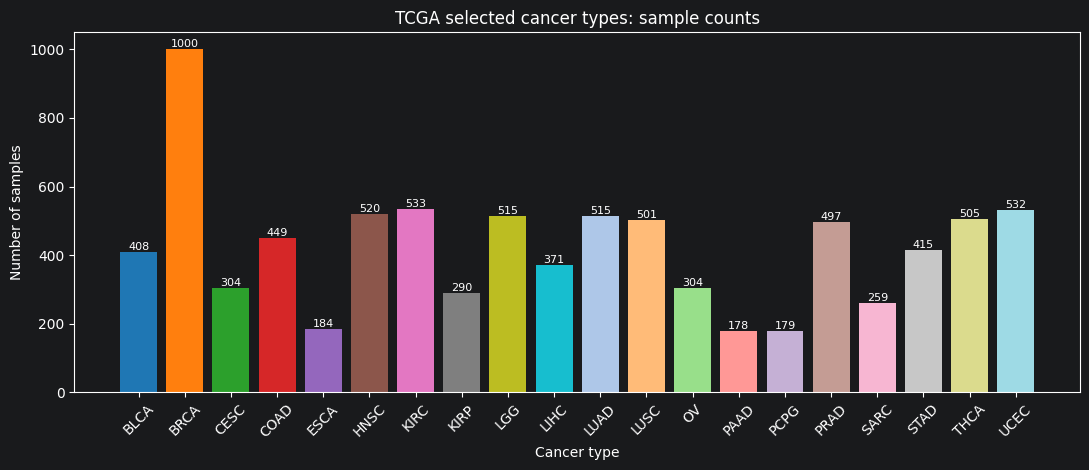

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/expression_distribution.png


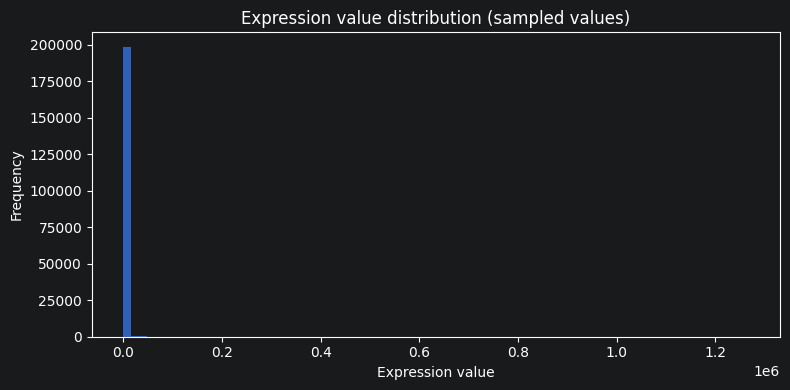

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/cancer_type_palette_preview.png


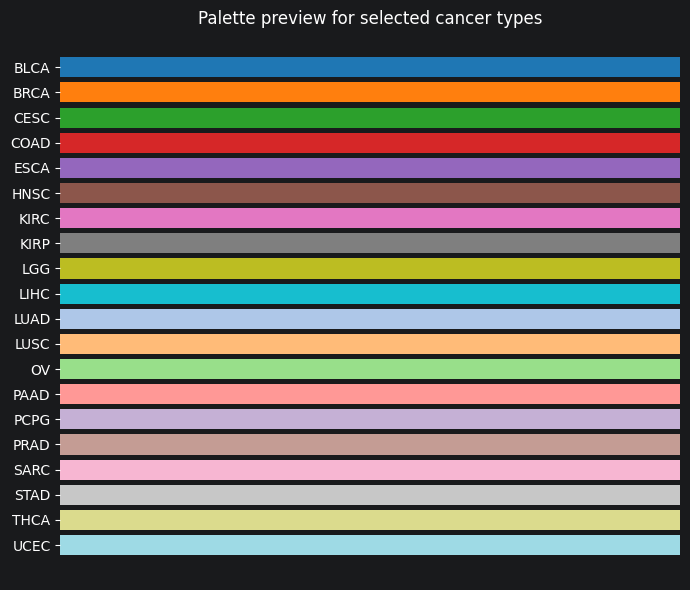

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Palette preview for selected cancer types'}>)

In [5]:
plot_class_counts(
    y,
    title="TCGA selected cancer types: sample counts",
    save_path=cfg.figure_dir / "class_counts.png",
)

plot_expression_distribution(
    X,
    title="Expression value distribution (sampled values)",
    save_path=cfg.figure_dir / "expression_distribution.png",
)

plot_palette_preview(
    y,
    title="Palette preview for selected cancer types",
    save_path=cfg.figure_dir / "cancer_type_palette_preview.png",
)


## 6. 모델링 전 차원축소 시각화

고차원 gene expression 데이터를 바로 이해하기 어렵기 때문에 PCA와 t-SNE/UMAP으로 2차원에 투영한다.  
이 단계는 **정답을 맞히는 모델링 전**, 데이터 자체에 암종 구분 신호가 있는지 확인하는 EDA이다.

PCA, t-SNE, UMAP은 NaN을 직접 처리하지 못하므로, EDA용 matrix에서는 다음 처리를 먼저 수행한다.

1. 결측 비율이 너무 높은 gene 제거
2. 남은 작은 결측치는 gene별 median으로 대치
3. 분산이 큰 gene 선택
4. StandardScaler 적용

20개 암종으로 데이터가 커지면 t-SNE/UMAP이 오래 걸릴 수 있으므로, nonlinear embedding에는 class 비율을 유지한 stratified sample을 사용한다. 실제 모델 학습용 전처리는 뒤에서 train/test split 이후 train set에만 fit한다.


EDA matrix shape: (8459, 2000)
Selected genes for EDA: 2000
NaN after EDA preprocessing: 0


,item,value
0,eda_input_genes,20501
1,eda_genes_after_missing_filter,20501
2,eda_selected_top_variable_genes,2000
3,eda_remaining_missing_values,0


PCA explained variance ratio: [0.07615453 0.06934382]
[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_pca_raw_expression.png


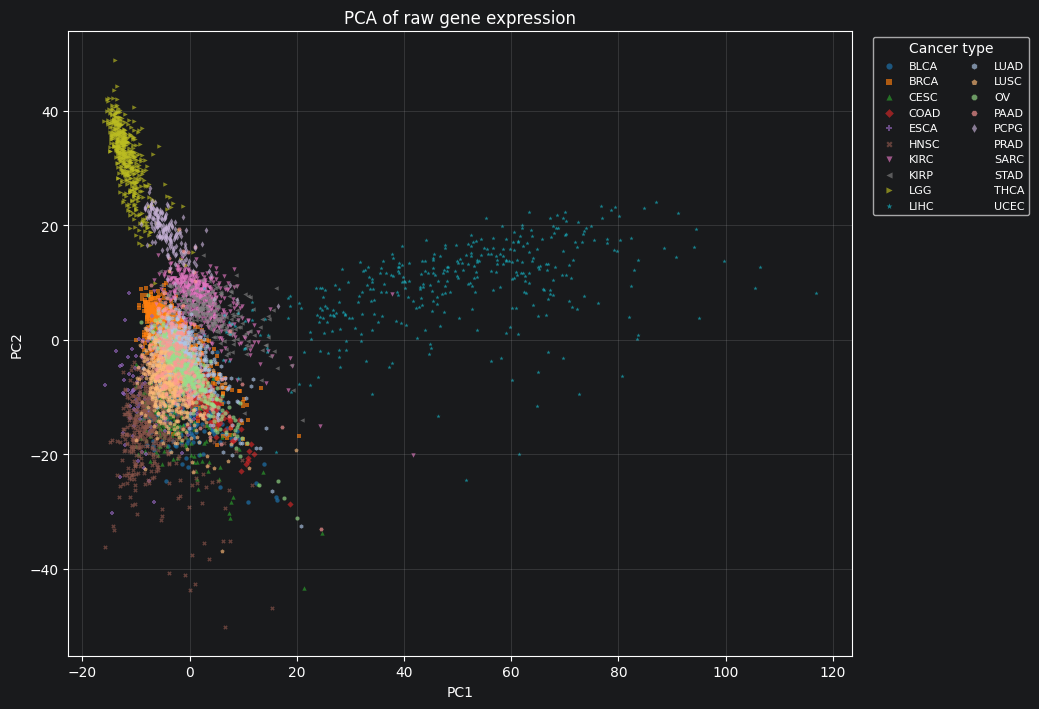

(<Figure size 1050x720 with 1 Axes>,
 <Axes: title={'center': 'PCA of raw gene expression'}, xlabel='PC1', ylabel='PC2'>)

In [6]:
# EDA용으로 전체 데이터에서 분산이 큰 gene만 간단히 선택한다.
# 실제 모델 학습용 feature selection/imputation은 뒤에서 train set에만 fit한다.
X_eda_scaled, eda_genes, eda_report = prepare_eda_matrix(
    X,
    top_n_genes=cfg.top_n_genes,
    max_missing_fraction=cfg.max_missing_fraction,
)

print(f"EDA matrix shape: {X_eda_scaled.shape}")
print(f"Selected genes for EDA: {len(eda_genes)}")
print(f"NaN after EDA preprocessing: {np.isnan(X_eda_scaled).sum()}")
display(eda_report)
save_table(eda_report, cfg.table_dir / "eda_preprocessing_report.csv")

pca_emb, pca_model = compute_pca(X_eda_scaled, n_components=2, random_state=cfg.random_state)
print("PCA explained variance ratio:", pca_model.explained_variance_ratio_)

plot_embedding(
    pca_emb,
    y,
    title="PCA of raw gene expression",
    xlabel="PC1",
    ylabel="PC2",
    save_path=cfg.figure_dir / "eda_pca_raw_expression.png",
    size=10 if len(y) > 3000 else 14,
    alpha=0.65 if len(y) > 3000 else 0.75,
)

Embedding sample size: 3000 / 8459
[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_umap_raw_expression.png


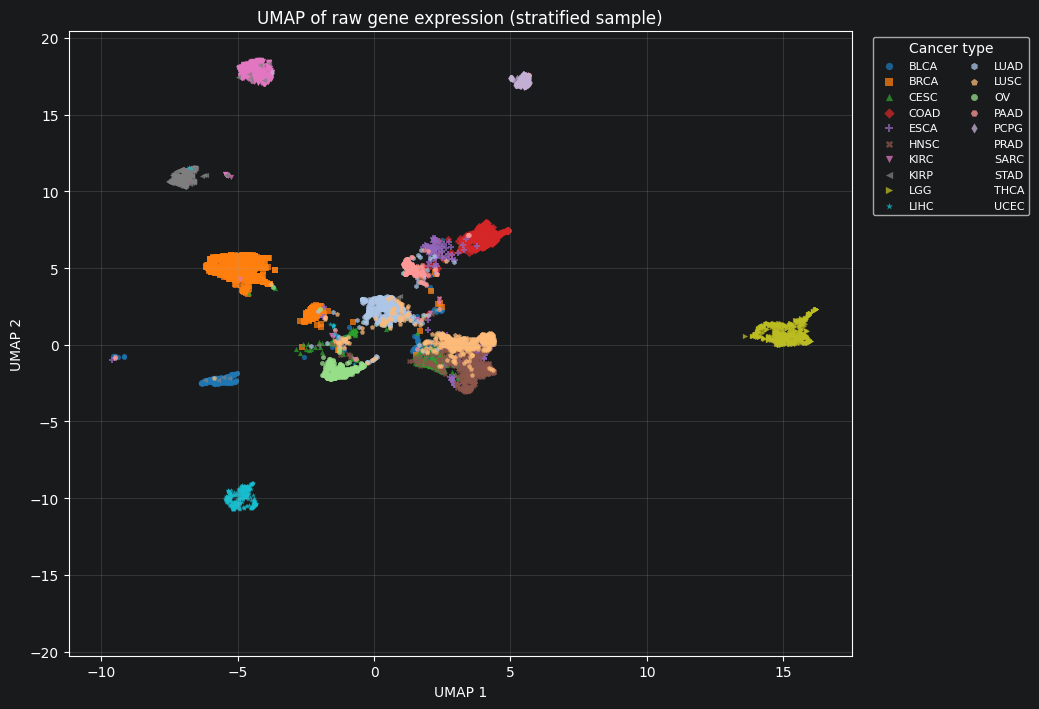

(<Figure size 1050x720 with 1 Axes>,
 <Axes: title={'center': 'UMAP of raw gene expression (stratified sample)'}, xlabel='UMAP 1', ylabel='UMAP 2'>)

In [18]:
# t-SNE 또는 UMAP 시각화. UMAP 미설치 시 자동으로 t-SNE를 사용한다.
# 20개 암종에서는 전체 데이터를 모두 넣기보다 stratified sample을 사용하는 것이 발표용 그림에 적합하다.
eda_embed_idx = stratified_sample_indices(
    y,
    max_samples=cfg.max_samples_for_embedding,
    random_state=cfg.random_state,
)
print(f"Embedding sample size: {len(eda_embed_idx)} / {len(y)}")

X_eda_for_embed = X_eda_scaled[eda_embed_idx]
y_eda_for_embed = y.iloc[eda_embed_idx]

nonlinear_emb, nonlinear_name = compute_embedding(
    X_eda_for_embed,
    method=cfg.embedding_method,
    random_state=cfg.random_state,
)

plot_embedding(
    nonlinear_emb,
    y_eda_for_embed,
    title=f"{nonlinear_name} of raw gene expression (stratified sample)",
    xlabel=f"{nonlinear_name} 1",
    ylabel=f"{nonlinear_name} 2",
    save_path=cfg.figure_dir / f"eda_{nonlinear_name.lower().replace('-', '')}_raw_expression.png",
)


## 7. 전처리: train/test split, imputation, feature selection, scaling

데이터 누수(data leakage)를 막기 위해 아래 원칙을 지킨다.

1. 먼저 train/test split을 수행한다.
2. 결측 비율이 높은 gene 제거 기준은 train set에서만 계산한다.
3. median imputer는 train set에만 fit한다.
4. top variable gene selection은 train set에만 fit한다.
5. StandardScaler도 train set에만 fit하고 test set에는 transform만 적용한다.


In [8]:
prepared = prepare_model_data(
    X,
    y,
    top_n_genes=cfg.top_n_genes,
    test_size=cfg.test_size,
    random_state=cfg.random_state,
    max_missing_fraction=cfg.max_missing_fraction,
)

print("Train shape:", prepared.X_train.shape)
print("Test shape:", prepared.X_test.shape)
print("Selected feature count:", len(prepared.feature_names))
print("Class names:", prepared.class_names)
print("NaN in X_train:", np.isnan(prepared.X_train).sum())
print("NaN in X_test:", np.isnan(prepared.X_test).sum())

cleaning_report_df = pd.DataFrame([prepared.cleaning_report]).T.reset_index()
cleaning_report_df.columns = ["item", "value"]
display(cleaning_report_df)
save_table(cleaning_report_df, cfg.table_dir / "model_preprocessing_report.csv")

Train shape: (6767, 2000)
Test shape: (1692, 2000)
Selected feature count: 2000
Class names: ['BLCA', 'BRCA', 'CESC', 'COAD', 'ESCA', 'HNSC', 'KIRC', 'KIRP', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'OV', 'PAAD', 'PCPG', 'PRAD', 'SARC', 'STAD', 'THCA', 'UCEC']
NaN in X_train: 0
NaN in X_test: 0


,item,value
0,original_genes,2.050100e+04
1,original_missing_values,2.999955e+06
2,original_missing_fraction,1.729899e-02
3,genes_after_missing_variance_filter,2.027300e+04
4,selected_top_variable_genes,2.000000e+03
5,train_remaining_missing_values,0.000000e+00
6,test_remaining_missing_values,0.000000e+00


PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/model_preprocessing_report.csv')

## 8. Classical ML 모델 학습

기본을 확실히 보여주기 위해 다음 모델을 비교한다.

- Dummy majority baseline
- Logistic Regression L2
- Logistic Regression L1
- Random Forest

Logistic Regression은 해석 가능한 coefficient를 제공하고, Random Forest는 nonlinear baseline과 feature importance를 제공한다.

[fit] Dummy_majority
[fit] LogReg_L2
[fit] LogReg_L1
[fit] RandomForest

  Classical model performance


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr_macro
0,RandomForest,0.964539,0.955114,0.962652,0.955114,0.957724,0.965556,0.964539,0.964268,0.998943
1,LogReg_L1,0.960402,0.958351,0.952163,0.958351,0.954576,0.961478,0.960402,0.960411,0.997483
2,LogReg_L2,0.959811,0.953028,0.953027,0.953028,0.952627,0.960383,0.959811,0.959716,0.997998
3,Dummy_majority,0.118203,0.050000,0.005910,0.050000,0.010571,0.013972,0.118203,0.024990,0.500000


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/classical_model_macro_f1.png


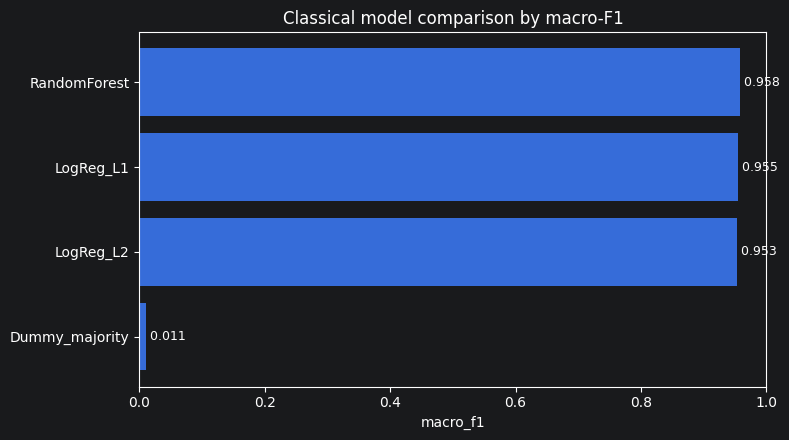

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Classical model comparison by macro-F1'}, xlabel='macro_f1'>)

In [9]:
models = build_classical_models(
    random_state=cfg.random_state,
    run_l1=cfg.run_l1_logreg,
    run_random_forest=cfg.run_random_forest,
)

fitted_models = fit_classical_models(models, prepared.X_train, prepared.y_train)
metrics_df, predictions, probabilities = evaluate_models(fitted_models, prepared.X_test, prepared.y_test)

print_section("Classical model performance")
display(metrics_df)
save_table(metrics_df, cfg.table_dir / "classical_model_metrics.csv")

plot_metrics_table(
    metrics_df,
    metric="macro_f1",
    title="Classical model comparison by macro-F1",
    save_path=cfg.figure_dir / "classical_model_macro_f1.png",
)

## 9. Confusion Matrix와 class별 성능 해석

Accuracy 하나만으로 끝내지 않고, 어떤 암종이 잘 맞고 어떤 암종이 헷갈리는지 확인한다.

여기서 중요한 수정점은 **confusion matrix를 raw count가 아니라 row-normalized matrix로 시각화**한다는 것이다.  
raw count heatmap은 BRCA처럼 sample 수가 큰 class가 단순히 더 밝게 보일 수 있다. Row-normalized confusion matrix는 각 true class 행을 100%로 맞추므로, 색깔이 class별 정답률/오답률을 반영한다.


Best classical model: RandomForest

  Row-normalized confusion matrix


,BLCA,BRCA,CESC,COAD,ESCA,HNSC,KIRC,KIRP,LGG,LIHC,LUAD,LUSC,OV,PAAD,PCPG,PRAD,SARC,STAD,THCA,UCEC
BLCA,97.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.2%,0.0%,0.0%,0.0%,0.0%,0.0%,1.2%,0.0%,0.0%,0.0%
BRCA,0.0%,98.5%,0.5%,0.0%,0.0%,0.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.5%,0.0%,0.0%,0.0%
CESC,0.0%,3.3%,90.2%,0.0%,0.0%,1.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,4.9%
COAD,1.1%,0.0%,0.0%,98.9%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
ESCA,0.0%,0.0%,0.0%,0.0%,70.3%,2.7%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,27.0%,0.0%,0.0%
HNSC,0.0%,0.0%,0.0%,0.0%,0.0%,97.1%,0.0%,0.0%,0.0%,0.0%,0.0%,1.0%,0.0%,0.0%,0.0%,0.0%,1.9%,0.0%,0.0%,0.0%
KIRC,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,98.1%,0.9%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.9%,0.0%,0.0%,0.0%
KIRP,1.7%,0.0%,0.0%,0.0%,0.0%,0.0%,6.9%,91.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
LGG,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,99.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.0%,0.0%,0.0%,0.0%
LIHC,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.4%,0.0%,97.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.4%,0.0%,0.0%,0.0%



  Raw count confusion matrix


,BLCA,BRCA,CESC,COAD,ESCA,HNSC,KIRC,KIRP,LGG,LIHC,LUAD,LUSC,OV,PAAD,PCPG,PRAD,SARC,STAD,THCA,UCEC
BLCA,80,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
BRCA,0,197,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
CESC,0,2,55,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3
COAD,1,0,0,89,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ESCA,0,0,0,0,26,1,0,0,0,0,0,0,0,0,0,0,0,10,0,0
HNSC,0,0,0,0,0,101,0,0,0,0,0,1,0,0,0,0,2,0,0,0
KIRC,0,0,0,0,0,0,105,1,0,0,0,0,0,0,0,0,1,0,0,0
KIRP,1,0,0,0,0,0,4,53,0,0,0,0,0,0,0,0,0,0,0,0
LGG,0,0,0,0,0,0,0,0,102,0,0,0,0,0,0,0,1,0,0,0
LIHC,0,0,0,0,0,0,0,1,0,72,0,0,0,0,0,0,1,0,0,0


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/confusion_matrix_row_normalized_RandomForest.png


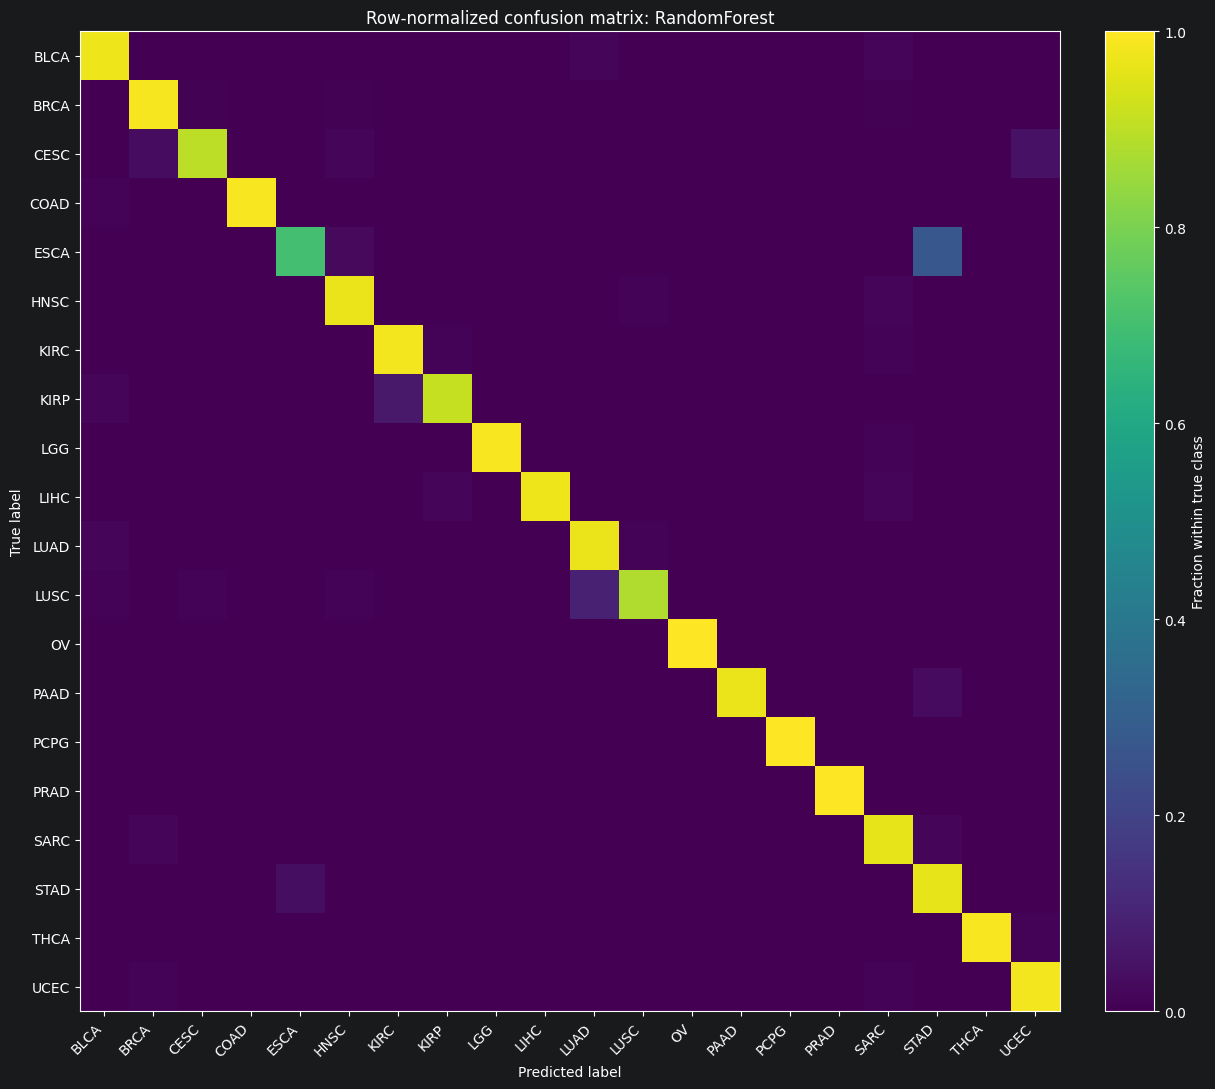


  Classification report


,class,precision,recall,f1-score,support
0,BLCA,0.941176,0.975610,0.958084,82.000000
1,BRCA,0.980100,0.985000,0.982544,200.000000
2,CESC,0.964912,0.901639,0.932203,61.000000
3,COAD,1.000000,0.988889,0.994413,90.000000
4,ESCA,0.896552,0.702703,0.787879,37.000000
5,HNSC,0.961905,0.971154,0.966507,104.000000
6,KIRC,0.963303,0.981308,0.972222,107.000000
7,KIRP,0.963636,0.913793,0.938053,58.000000
8,LGG,1.000000,0.990291,0.995122,103.000000
9,LIHC,1.000000,0.972973,0.986301,74.000000



  Per-class accuracy/recall


,class,support,correct,class_accuracy_recall
0,BLCA,82,80,0.975610
1,BRCA,200,197,0.985000
2,CESC,61,55,0.901639
3,COAD,90,89,0.988889
4,ESCA,37,26,0.702703
5,HNSC,104,101,0.971154
6,KIRC,107,105,0.981308
7,KIRP,58,53,0.913793
8,LGG,103,102,0.990291
9,LIHC,74,72,0.972973


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/per_class_recall_RandomForest.png


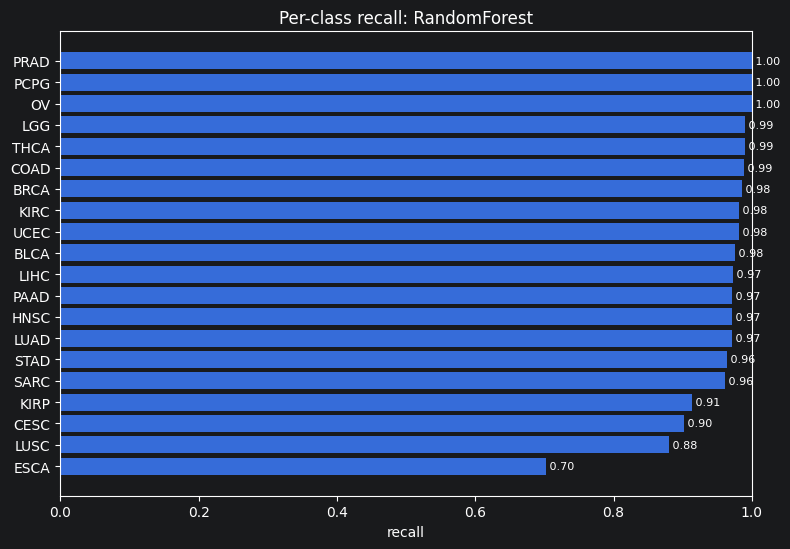


  Top confusion pairs, normalized by true class


,true_class,predicted_class,count,error_rate_within_true_class
0,ESCA,STAD,10,0.270270
1,LUSC,LUAD,9,0.090000
2,KIRP,KIRC,4,0.068966
3,CESC,UCEC,3,0.049180
4,STAD,ESCA,3,0.036145
5,CESC,BRCA,2,0.032787
6,PAAD,STAD,1,0.028571
7,ESCA,HNSC,1,0.027027
8,LUAD,BLCA,2,0.019417
9,HNSC,SARC,2,0.019231


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/top_confusion_pairs_RandomForest.png


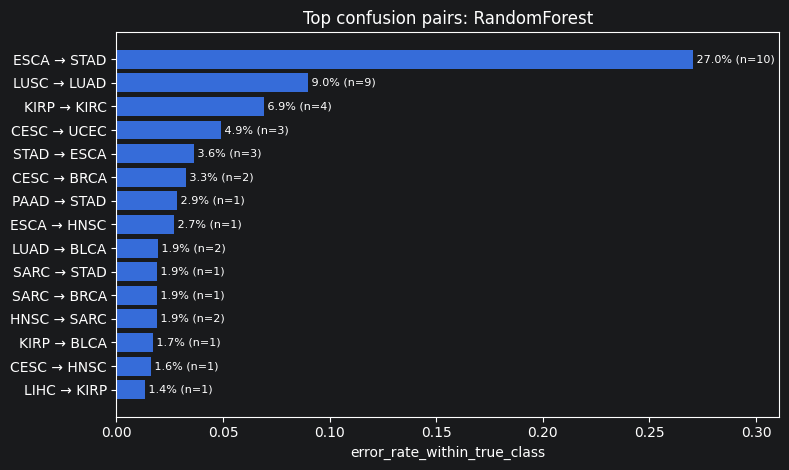

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Top confusion pairs: RandomForest'}, xlabel='error_rate_within_true_class'>)

In [10]:
best_classical_name = get_best_model_name(metrics_df, metric="macro_f1")
best_classical_pred = predictions[best_classical_name]
print("Best classical model:", best_classical_name)

# Raw count matrix는 table로 보관하고, 발표용 heatmap은 row-normalized matrix를 사용한다.
# normalize="true"는 각 실제 class(row)를 1로 나누므로, 색은 class별 recall/정답률을 의미한다.
cm_counts_df = confusion_matrix_df(
    prepared.y_test,
    best_classical_pred,
    class_names=prepared.class_names,
    normalize=None,
)
cm_norm_df = confusion_matrix_df(
    prepared.y_test,
    best_classical_pred,
    class_names=prepared.class_names,
    normalize="true",
).fillna(0)

print_section("Row-normalized confusion matrix")
display(cm_norm_df.style.format("{:.1%}"))

print_section("Raw count confusion matrix")
display(cm_counts_df)

save_table(cm_counts_df, cfg.table_dir / f"confusion_matrix_counts_{best_classical_name}.csv")
save_table(cm_norm_df, cfg.table_dir / f"confusion_matrix_row_normalized_{best_classical_name}.csv")

plot_confusion_matrix(
    cm_norm_df,
    title=f"Row-normalized confusion matrix: {best_classical_name}",
    normalize=True,
    counts=cm_counts_df,
    show_counts=False,
    vmin=0,
    vmax=1,
    cbar_label="Fraction within true class",
    save_path=cfg.figure_dir / f"confusion_matrix_row_normalized_{best_classical_name}.png",
)

report_df = classification_report_df(prepared.y_test, best_classical_pred, prepared.class_names)
print_section("Classification report")
display(report_df)
save_table(report_df, cfg.table_dir / f"classification_report_{best_classical_name}.csv")

per_class_df = per_class_accuracy_df(prepared.y_test, best_classical_pred, prepared.class_names)
print_section("Per-class accuracy/recall")
display(per_class_df)
save_table(per_class_df, cfg.table_dir / f"per_class_accuracy_{best_classical_name}.csv")

plot_per_class_metric(
    report_df,
    metric="recall",
    title=f"Per-class recall: {best_classical_name}",
    save_path=cfg.figure_dir / f"per_class_recall_{best_classical_name}.png",
)

confusion_pairs_df = top_confusion_pairs(
    prepared.y_test,
    best_classical_pred,
    prepared.class_names,
    top_n=15,
)
print_section("Top confusion pairs, normalized by true class")
display(confusion_pairs_df)
save_table(confusion_pairs_df, cfg.table_dir / f"top_confusion_pairs_{best_classical_name}.csv")

plot_top_confusion_pairs(
    confusion_pairs_df,
    title=f"Top confusion pairs: {best_classical_name}",
    save_path=cfg.figure_dir / f"top_confusion_pairs_{best_classical_name}.png",
)

## 10. 해석 가능한 candidate marker gene 정리

이 단계의 목적은 새로운 바이오마커를 확정하는 것이 아니라, **분류 모델이 암종 구분에 중요하게 사용한 candidate gene**을 정리하는 것이다.

In [11]:
interpretation_tables = []

if "LogReg_L2" in fitted_models:
    logreg_l2_top = logistic_top_genes(
        fitted_models["LogReg_L2"],
        feature_names=prepared.feature_names,
        class_names=prepared.class_names,
        top_n=15,
    )
    print_section("Top genes from L2 Logistic Regression coefficients")
    display(logreg_l2_top.head(30))
    save_table(logreg_l2_top, cfg.table_dir / "top_genes_logreg_l2.csv")
    interpretation_tables.append(logreg_l2_top)

if "LogReg_L1" in fitted_models:
    l1_nonzero = logistic_nonzero_genes(
        fitted_models["LogReg_L1"],
        feature_names=prepared.feature_names,
    )
    print_section("Non-zero genes from L1 Logistic Regression")
    print("Number of non-zero genes:", len(l1_nonzero))
    display(l1_nonzero.head(30))
    save_table(l1_nonzero, cfg.table_dir / "nonzero_genes_logreg_l1.csv")
    interpretation_tables.append(l1_nonzero.head(100))

if "RandomForest" in fitted_models:
    rf_top = random_forest_top_genes(
        fitted_models["RandomForest"],
        feature_names=prepared.feature_names,
        top_n=30,
    )
    print_section("Top genes from Random Forest feature importance")
    display(rf_top.head(30))
    save_table(rf_top, cfg.table_dir / "top_genes_random_forest.csv")
    interpretation_tables.append(rf_top)

if interpretation_tables:
    overlap_df = overlapping_top_genes(*interpretation_tables)
    print_section("Genes repeatedly selected by multiple interpretation methods")
    display(overlap_df.head(30))
    save_table(overlap_df, cfg.table_dir / "overlapping_top_genes.csv")


  Top genes from L2 Logistic Regression coefficients


,class,rank,gene,coef,class_direction_score,abs_coef
0,BLCA,1,CYP4B1,0.250957,0.250957,0.250957
1,BLCA,2,SNCG,0.201735,0.201735,0.201735
2,BLCA,3,SHISA5,0.189940,0.189940,0.189940
3,BLCA,4,PLAT,0.185961,0.185961,0.185961
4,BLCA,5,RCN1,0.178375,0.178375,0.178375
5,BLCA,6,CEACAM7,0.174198,0.174198,0.174198
6,BLCA,7,NET1,0.172420,0.172420,0.172420
7,BLCA,8,HMGB1,0.153195,0.153195,0.153195
8,BLCA,9,UPK1B,0.148761,0.148761,0.148761
9,BLCA,10,PPP1CA,0.144178,0.144178,0.144178



  Non-zero genes from L1 Logistic Regression
Number of non-zero genes: 1416


,gene,max_abs_coef
0,ANXA2P2,3.659273
1,ANXA2,3.612150
2,TSHR,2.521086
3,HOXB13,1.775569
4,RPL17,1.691338
5,APH1A,1.645392
6,RPL12,1.627833
7,RPS4Y1,1.547686
8,MSX1,1.409498
9,INS,1.281032



  Top genes from Random Forest feature importance


,rank,gene,importance
0,1,PAX8,0.008129
1,2,TSHR,0.006483
2,3,CELA3A,0.006234
3,4,TG,0.006070
4,5,ACSM2B,0.005696
5,6,SFTPB,0.005613
6,7,INS,0.005321
7,8,KLK3,0.005166
8,9,ACSM2A,0.005057
9,10,SFTPA2,0.005043



  Genes repeatedly selected by multiple interpretation methods


,gene,n_tables
0,GATA3,3
1,INS,3
2,NKX3-1,3
3,TSHR,3
4,ACSM2B,2
5,AHR,2
6,ANXA2P2,2
7,ANXA4,2
8,ATP2C1,2
9,C19orf63,2


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/top_genes_logreg_BLCA.png


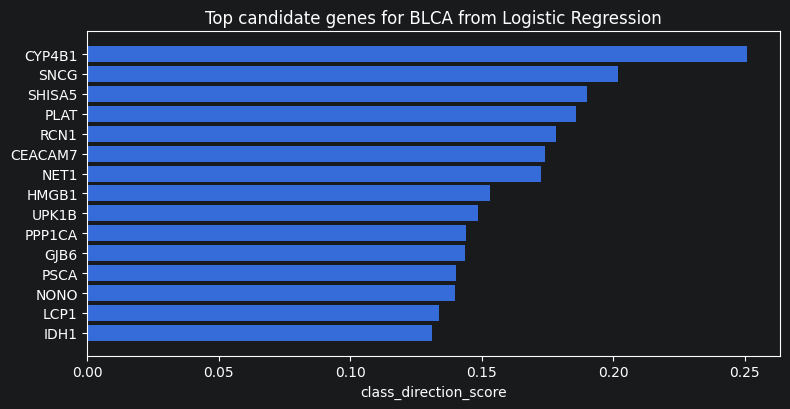

In [12]:
# 예시: 첫 번째 암종에 대한 Logistic Regression top genes 시각화
if "LogReg_L2" in fitted_models:
    example_class = prepared.class_names[0]
    plot_df = logreg_l2_top[logreg_l2_top["class"] == example_class].copy()
    plot_top_genes(
        plot_df,
        score_col="class_direction_score",
        title=f"Top candidate genes for {example_class} from Logistic Regression",
        top_n=15,
        save_path=cfg.figure_dir / f"top_genes_logreg_{example_class}.png",
    )

## 11. MLP 모델 학습

기존 랩의 MLP 구조를 확장해 TCGA 데이터에 적용한다.  
여기서 MLP는 단순히 성능 비교용일 뿐 아니라, hidden layer의 latent representation을 추출하기 위한 모델이다.


  Training MLP
Epoch 001 | train_loss=0.8698 | val_loss=0.2697 | val_acc=0.924
Epoch 010 | train_loss=0.0053 | val_loss=0.1782 | val_acc=0.968
Epoch 020 | train_loss=0.0020 | val_loss=0.1957 | val_acc=0.967
[early stopping] No validation loss improvement for 15 epochs.


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr_macro
0,MLP,0.95922,0.956639,0.952537,0.956639,0.95359,0.961083,0.95922,0.959334,0.998369


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/mlp_training_history.png


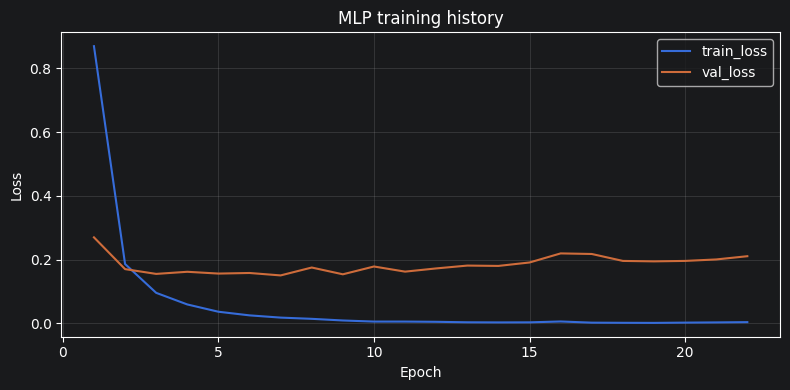

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/confusion_matrix_row_normalized_mlp.png


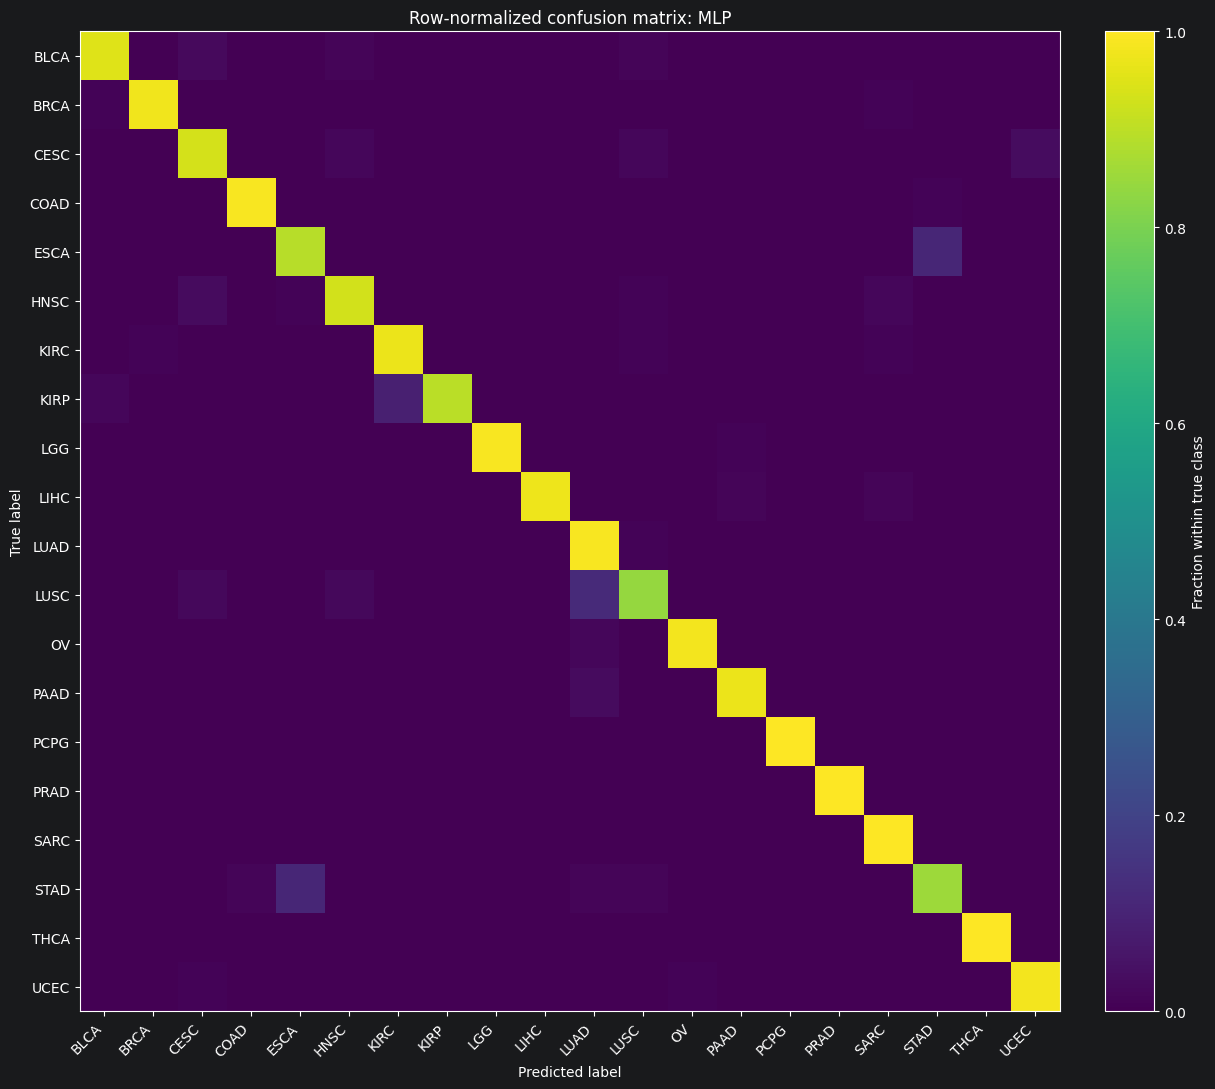


  Top off-diagonal confusion pairs: MLP


,true_class,predicted_class,count,error_rate_within_true_class
0,LUSC,LUAD,12,0.120000
1,STAD,ESCA,9,0.108434
2,ESCA,STAD,4,0.108108
3,KIRP,KIRC,5,0.086207
4,CESC,UCEC,2,0.032787
5,HNSC,CESC,3,0.028846
6,PAAD,LUAD,1,0.028571
7,BLCA,CESC,2,0.024390
8,LUSC,CESC,2,0.020000
9,LUSC,HNSC,2,0.020000


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/top_confusion_pairs_mlp.png


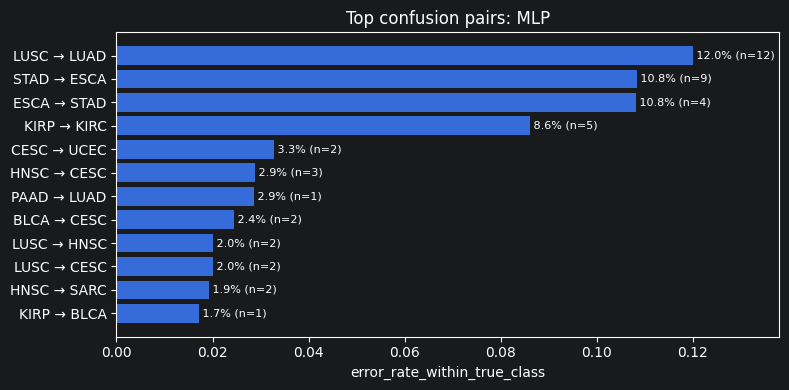

In [13]:
mlp_result = None
mlp_metrics_df = pd.DataFrame()
latent_all = None

if cfg.run_mlp and torch_available():
    print_section("Training MLP")
    mlp_result = train_mlp_classifier(
        prepared.X_train,
        prepared.y_train,
        prepared.X_test,
        prepared.y_test,
        n_classes=len(prepared.class_names),
        hidden_dim=cfg.mlp_hidden_dim,
        latent_dim=cfg.mlp_latent_dim,
        dropout=cfg.mlp_dropout,
        epochs=cfg.mlp_epochs,
        batch_size=cfg.mlp_batch_size,
        learning_rate=cfg.mlp_learning_rate,
        patience=cfg.mlp_patience,
        random_state=cfg.random_state,
        verbose=True,
    )
    mlp_metrics_df = pd.DataFrame([{ "model": "MLP", **mlp_result.metrics }])
    display(mlp_metrics_df)
    save_table(mlp_metrics_df, cfg.table_dir / "mlp_metrics.csv")

    plot_training_history(
        mlp_result.history,
        save_path=cfg.figure_dir / "mlp_training_history.png",
    )

    mlp_cm_counts_df = confusion_matrix_df(
        prepared.y_test,
        mlp_result.y_pred,
        class_names=prepared.class_names,
        normalize=None,
    )
    mlp_cm_norm_df = confusion_matrix_df(
        prepared.y_test,
        mlp_result.y_pred,
        class_names=prepared.class_names,
        normalize="true",
    )
    save_table(mlp_cm_counts_df, cfg.table_dir / "confusion_matrix_counts_mlp.csv")
    save_table(mlp_cm_norm_df, cfg.table_dir / "confusion_matrix_row_normalized_mlp.csv")

    plot_confusion_matrix(
        mlp_cm_norm_df,
        title="Row-normalized confusion matrix: MLP",
        normalize=True,
        counts=mlp_cm_counts_df,
        show_counts=False,
        vmin=0,
        vmax=1,
        cbar_label="Fraction within true class",
        save_path=cfg.figure_dir / "confusion_matrix_row_normalized_mlp.png",
    )

    mlp_confusion_pairs_df = top_confusion_pairs(
        prepared.y_test,
        mlp_result.y_pred,
        prepared.class_names,
        top_n=12,
    )
    print_section("Top off-diagonal confusion pairs: MLP")
    display(mlp_confusion_pairs_df)
    save_table(mlp_confusion_pairs_df, cfg.table_dir / "top_confusion_pairs_mlp.csv")
    plot_top_confusion_pairs(
        mlp_confusion_pairs_df,
        title="Top confusion pairs: MLP",
        save_path=cfg.figure_dir / "top_confusion_pairs_mlp.png",
    )

    latent_all = encode_mlp_latent(
        mlp_result.model,
        prepared.X_all_scaled,
        device=mlp_result.device,
    )
else:
    print("MLP skipped. cfg.run_mlp is False or PyTorch is not installed.")


## 12. 전체 모델 성능 비교

Classical ML과 MLP 결과를 하나의 표로 합친다.

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr_macro
0,RandomForest,0.964539,0.955114,0.962652,0.955114,0.957724,0.965556,0.964539,0.964268,0.998943
1,LogReg_L1,0.960402,0.958351,0.952163,0.958351,0.954576,0.961478,0.960402,0.960411,0.997483
2,MLP,0.959220,0.956639,0.952537,0.956639,0.953590,0.961083,0.959220,0.959334,0.998369
3,LogReg_L2,0.959811,0.953028,0.953027,0.953028,0.952627,0.960383,0.959811,0.959716,0.997998
4,Dummy_majority,0.118203,0.050000,0.005910,0.050000,0.010571,0.013972,0.118203,0.024990,0.500000


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/all_model_macro_f1.png


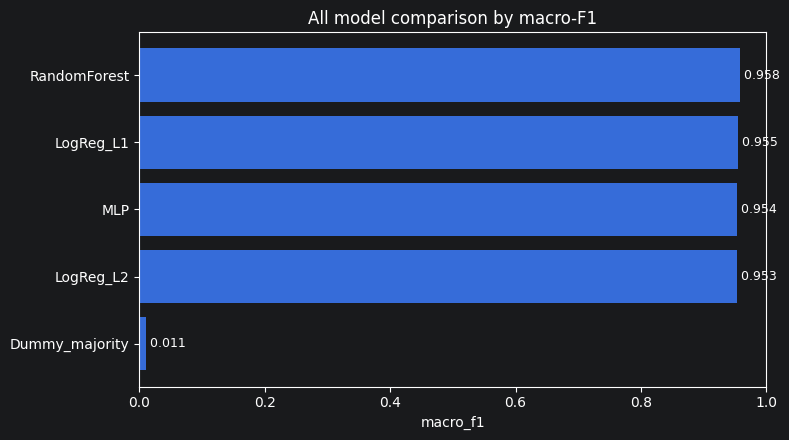

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/final_confusion_matrix_rownormalized_RandomForest.png


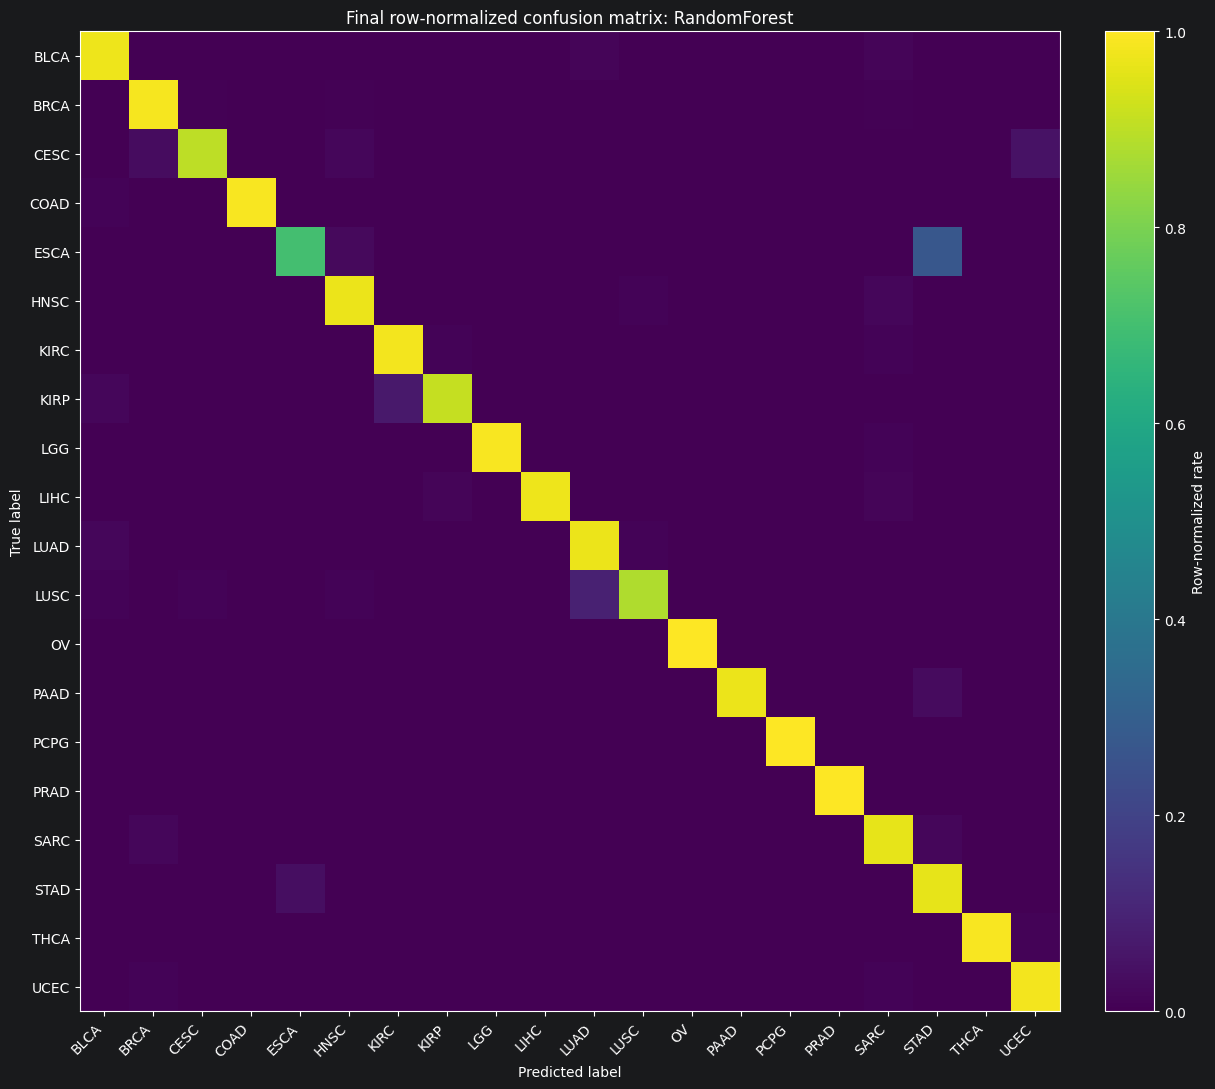

PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/final_confusion_matrix_rownorm_RandomForest.csv')

In [14]:
all_metrics_df = pd.concat([metrics_df, mlp_metrics_df], ignore_index=True)
all_metrics_df = all_metrics_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(all_metrics_df)
save_table(all_metrics_df, cfg.table_dir / "all_model_metrics.csv")

plot_metrics_table(
    all_metrics_df,
    metric="macro_f1",
    title="All model comparison by macro-F1",
    save_path=cfg.figure_dir / "all_model_macro_f1.png",
)

# Final presentation figure: normalized confusion matrix for the best overall model.
all_predictions = dict(predictions)
if mlp_result is not None:
    all_predictions["MLP"] = mlp_result.y_pred

best_overall_name = all_metrics_df.iloc[0]["model"]
best_overall_pred = all_predictions[best_overall_name]

best_cm_count_df = confusion_matrix_df(
    prepared.y_test,
    best_overall_pred,
    class_names=prepared.class_names,
    normalize=None,
)
best_cm_norm_df = confusion_matrix_df(
    prepared.y_test,
    best_overall_pred,
    class_names=prepared.class_names,
    normalize="true",
).fillna(0)

plot_confusion_matrix(
    best_cm_norm_df,
    title=f"Final row-normalized confusion matrix: {best_overall_name}",
    normalize=True,
    counts=best_cm_count_df,
    show_counts=False,
    save_path=cfg.figure_dir / f"final_confusion_matrix_rownormalized_{best_overall_name}.png",
)

save_table(best_cm_count_df, cfg.table_dir / f"final_confusion_matrix_counts_{best_overall_name}.csv")
save_table(best_cm_norm_df, cfg.table_dir / f"final_confusion_matrix_rownorm_{best_overall_name}.csv")

## 13. Feature selection 크기 비교: 2,000 genes vs all usable genes

Main pipeline은 발표와 해석을 쉽게 하기 위해 top variable genes를 사용한다.  
추가로, 같은 Logistic Regression 기준에서 아래 두 조건을 비교한다.

1. **Top 2,000 variable genes**: train set에서 분산이 큰 2,000개 gene만 사용
2. **All usable genes**: train set 기준 결측/분산 filtering 이후 남은 gene 전체 사용

이 비교는 전체 gene을 쓰는 것이 성능상 항상 유리한지, 그리고 계산 비용은 얼마나 늘어나는지 확인하기 위한 보조 실험이다.



  Feature set size comparison

[feature-set comparison] Top 2,000 variable genes

[feature-set comparison] All usable genes


,feature_set,model,requested_top_n_genes,n_original_genes,n_genes_after_missing_variance_filter,n_features_used,missing_fraction_original,runtime_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr_macro
0,All usable genes,LogReg_L2_saga,all,20501,20273,20273,0.017299,1141.805339,0.969267,0.965442,0.963349,0.965442,0.963849,0.970290,0.969267,0.969305,0.999145
1,"Top 2,000 variable genes",LogReg_L2_saga,2000,20501,20273,2000,0.017299,120.579991,0.959811,0.955137,0.952952,0.955137,0.953716,0.960348,0.959811,0.959804,0.998703


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/feature_set_size_comparison_logreg.png


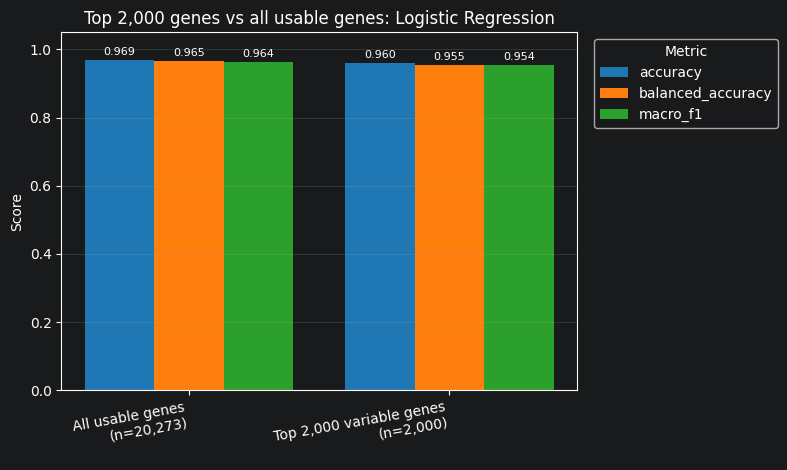

In [15]:
feature_comparison_df = pd.DataFrame()

if RUN_FEATURE_SET_COMPARISON:
    print_section("Feature set size comparison")
    feature_comparison_df = run_feature_set_size_comparison(
        X,
        y,
        feature_sets=FEATURE_SET_SPECS,
        test_size=cfg.test_size,
        random_state=cfg.random_state,
        max_missing_fraction=cfg.max_missing_fraction,
    )
    display(feature_comparison_df)
    save_table(feature_comparison_df, cfg.table_dir / "feature_set_size_comparison_logreg.csv")

    plot_feature_set_comparison(
        feature_comparison_df,
        metrics=("accuracy", "balanced_accuracy", "macro_f1"),
        title="Top 2,000 genes vs all usable genes: Logistic Regression",
        save_path=cfg.figure_dir / "feature_set_size_comparison_logreg.png",
    )
else:
    print("Feature-set size comparison skipped.")


## 14. MLP latent representation 분석

원본 expression feature space와 MLP hidden layer representation을 비교한다.  
발표에서는 이 그림을 통해 “모델이 암종별 구조를 어떻게 학습했는지”를 직관적으로 보여줄 수 있다.

PCA는 전체 sample로 그려도 비교적 빠르지만, t-SNE/UMAP은 20개 암종 전체 데이터를 모두 넣으면 느릴 수 있으므로 stratified sample을 사용한다.


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/model_input_pca.png


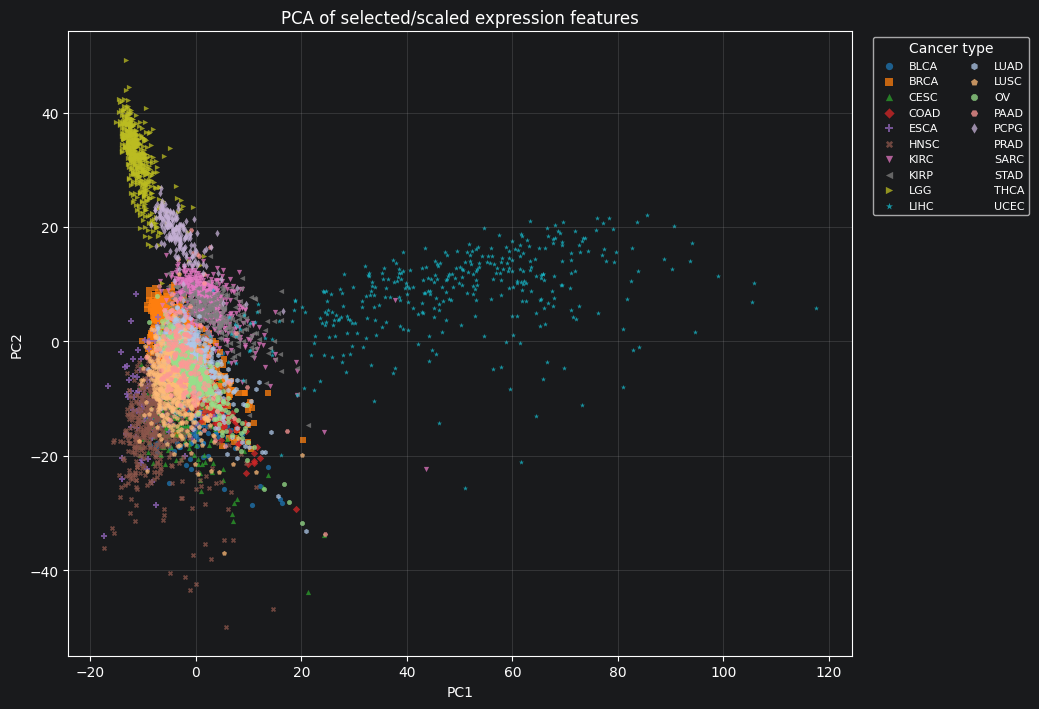

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/mlp_latent_pca.png


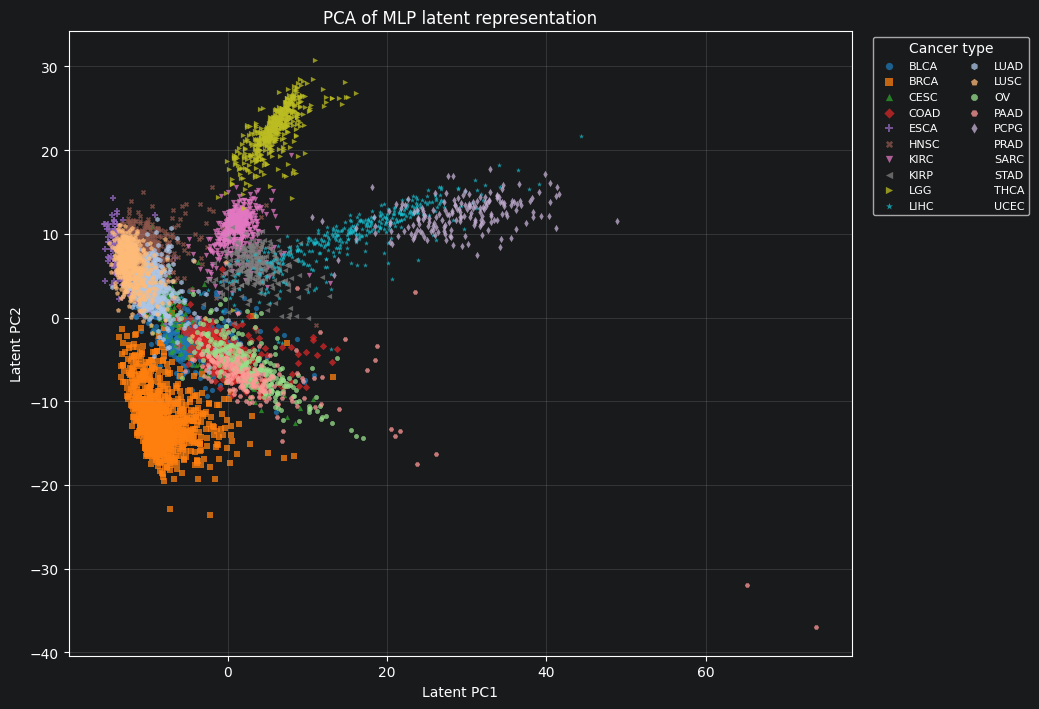

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/mlp_latent_umap.png


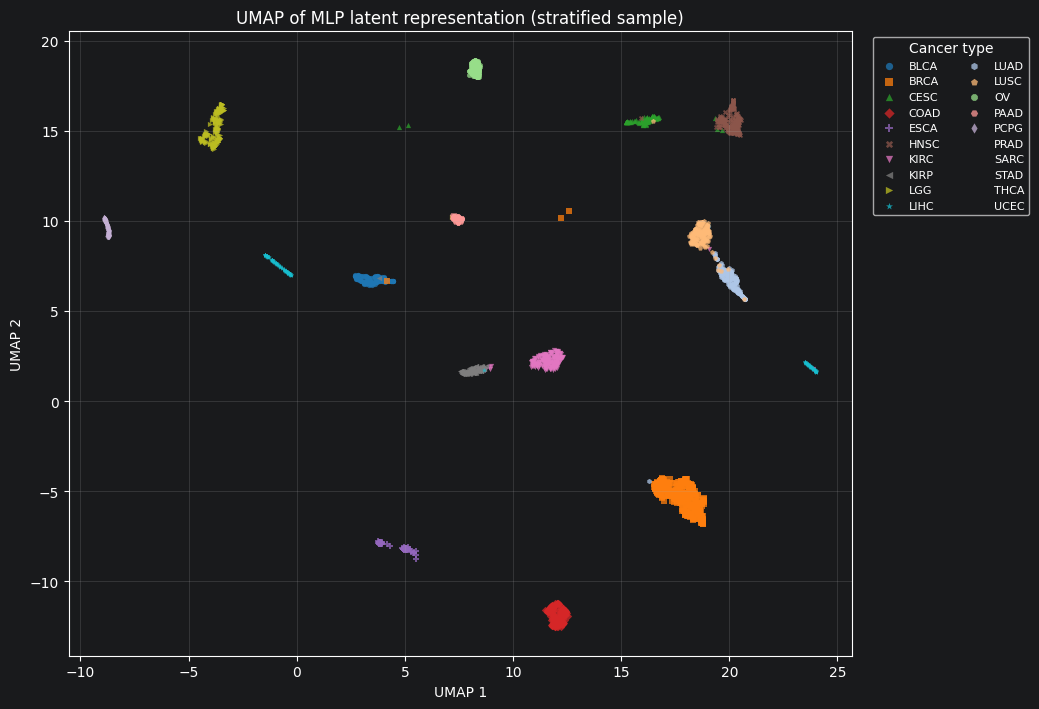

In [16]:
# Raw selected expression PCA
raw_pca_emb, raw_pca_model = compute_pca(prepared.X_all_scaled, n_components=2, random_state=cfg.random_state)
plot_embedding(
    raw_pca_emb,
    prepared.y_all_labels,
    title="PCA of selected/scaled expression features",
    xlabel="PC1",
    ylabel="PC2",
    save_path=cfg.figure_dir / "model_input_pca.png",
)

# MLP latent PCA and nonlinear embedding
if latent_all is not None:
    latent_pca_emb, latent_pca_model = compute_pca(latent_all, n_components=2, random_state=cfg.random_state)
    plot_embedding(
        latent_pca_emb,
        prepared.y_all_labels,
        title="PCA of MLP latent representation",
        xlabel="Latent PC1",
        ylabel="Latent PC2",
        save_path=cfg.figure_dir / "mlp_latent_pca.png",
    )

    latent_embed_idx = stratified_sample_indices(
        prepared.y_all_labels,
        max_samples=cfg.max_samples_for_embedding,
        random_state=cfg.random_state,
    )
    latent_nonlin_emb, latent_nonlin_name = compute_embedding(
        latent_all[latent_embed_idx],
        method=cfg.embedding_method,
        random_state=cfg.random_state,
    )
    plot_embedding(
        latent_nonlin_emb,
        prepared.y_all_labels.iloc[latent_embed_idx],
        title=f"{latent_nonlin_name} of MLP latent representation (stratified sample)",
        xlabel=f"{latent_nonlin_name} 1",
        ylabel=f"{latent_nonlin_name} 2",
        save_path=cfg.figure_dir / f"mlp_latent_{latent_nonlin_name.lower().replace('-', '')}.png",
    )
else:
    print("No MLP latent representation available.")


## 15. Clustering 보조 분석

정답 label 없이 K-means clustering을 했을 때 암종 구조가 얼마나 나타나는지 확인한다.  
여기서는 ARI, NMI, silhouette score를 사용한다.

In [ ]:
spaces = {}
raw_pca20, _ = compute_pca(
    prepared.X_all_scaled,
    n_components=min(20, prepared.X_all_scaled.shape[1], prepared.X_all_scaled.shape[0] - 1),
    random_state=cfg.random_state,
)
spaces["Expression PCA(20)"] = raw_pca20

if latent_all is not None:
    spaces["MLP latent"] = latent_all

cluster_df = compare_kmeans_spaces(
    spaces,
    y_true=prepared.y_all,
    n_clusters=len(prepared.class_names),
    random_state=cfg.random_state,
)

display(cluster_df)
save_table(cluster_df, cfg.table_dir / "clustering_comparison.csv")

## 16. 결과 요약 및 발표용 메시지

아래 셀은 보고서/발표에 바로 옮길 수 있는 핵심 산출물을 정리한다.

In [ ]:
print_section("Final summary")

best_overall = all_metrics_df.iloc[0]
print(f"Number of classes: {len(prepared.class_names)}")
print(f"Classes: {', '.join(prepared.class_names)}")
print(f"Best model: {best_overall['model']}")
print(f"Accuracy: {best_overall['accuracy']:.3f}")
print(f"Balanced accuracy: {best_overall['balanced_accuracy']:.3f}")
print(f"Macro-F1: {best_overall['macro_f1']:.3f}")
print("\nImportant evaluation notes:")
print("- 20-class scatter plots use an explicit tab20 categorical palette, not the default 10-color cycle.")
print("- Use row-normalized confusion matrix figures for presentation because raw counts are biased by class size.")
print("- Raw count matrices are still saved as CSV tables for transparency.")

if 'feature_comparison_df' in globals() and not feature_comparison_df.empty:
    print("\nFeature-set size comparison:")
    display(feature_comparison_df[["feature_set", "n_features_used", "accuracy", "balanced_accuracy", "macro_f1", "runtime_seconds"]])

print("\nSaved figures:")
for p in sorted(cfg.figure_dir.glob("*.png")):
    print("-", p)

print("\nSaved tables:")
for p in sorted(cfg.table_dir.glob("*.csv")):
    print("-", p)


## 17. Discussion 초안

- TCGA Pan-Cancer RNA-seq 데이터는 암종별 gene expression pattern을 충분히 포함하고 있어 multi-class classification에 적합했다.
- 20개 암종으로 확장하면서 class imbalance와 missing value 문제가 더 뚜렷하게 나타났고, 이를 전처리와 평가 지표에서 명시적으로 다루었다.
- Confusion matrix는 raw count가 아니라 row-normalized matrix를 주 그림으로 사용하여, sample 수가 많은 class가 시각적으로 과대평가되는 문제를 줄였다.
- Logistic Regression은 coefficient를 통해 class-specific candidate gene을 해석하기 쉽다는 장점이 있다.
- Random Forest는 nonlinear model로서 비교 기준이 되며, feature importance를 통해 추가적인 gene ranking을 제공한다.
- MLP는 hidden layer latent representation을 통해 암종별 발현 구조를 시각화하는 데 유용하다.
- 한계점은 다음과 같다.
  - 외부 검증 cohort를 사용하지 않았다.
  - batch effect를 깊게 보정하지 않았다.
  - candidate marker gene은 모델 기반 ranking이며, 생물학적 검증이 필요하다.
  - 실제 임상 진단 모델이 아니라 공개 데이터를 이용한 데이터 과학 프로세스 실습이다.
